In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
from tqdm.auto import tqdm
from tqdm import tqdm
from joblib import Parallel, delayed

In [152]:
sp500 = pd.read_csv("sp500_return.csv", parse_dates=['date'], index_col=0)
sp500_list = pd.read_csv("sp500_list.csv", index_col=0, parse_dates=['start','ending'])
stock_id = pd.read_csv("stock_id.csv", index_col=0, parse_dates=['namedt','nameendt'])

sp500 = sp500.loc["1960-01-01":]
sp500.columns = sp500.columns.astype(int)
orders = pd.DataFrame(index=sp500.index, columns=sp500.columns, data=0, dtype=float)
sp500_prices = (1+sp500).cumprod()
comnam_map = stock_id[["namedt", "permno", "comnam"]].drop_duplicates().groupby(["permno"])["comnam"].last()

In [ ]:
# sp500_prices = np.log(sp500_prices)

In [131]:
sp500_prices

,10006,10030,10057,10078,10102,10104,10107,10108,10137,10138,...,92988,93002,93089,93096,93132,93159,93246,93422,93429,93436
date,,,,,,,,,,,,,,,,,,,,,
1960-01-04,0.037931,0.000000e+00,0.011481,NaN,-0.005970,NaN,NaN,NaN,-0.024606,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-05,0.060019,0.000000e+00,0.002307,NaN,0.008889,NaN,NaN,NaN,-0.021054,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-06,0.060019,2.712867e-02,0.011482,NaN,-0.005970,NaN,NaN,NaN,-0.038944,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-07,0.045349,2.712867e-02,-0.002312,NaN,-0.011976,NaN,NaN,NaN,-0.046190,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-08,0.037932,-1.000000e-08,0.006904,NaN,-0.014992,NaN,NaN,NaN,-0.042560,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,NaN,NaN,NaN,NaN,NaN,8.108995,8.899414,NaN,NaN,5.859577,...,NaN,5.325307,2.364289,1.303203,4.075051,NaN,2.871249,NaN,2.034858,5.670731
2024-12-26,NaN,NaN,NaN,NaN,NaN,8.110569,8.896634,NaN,NaN,5.863923,...,NaN,5.348728,2.363679,1.316380,4.069721,NaN,2.879745,NaN,2.045806,5.652944
2024-12-27,NaN,NaN,NaN,NaN,NaN,8.094599,8.879180,NaN,NaN,5.847546,...,NaN,5.333906,2.359791,1.319812,4.057206,NaN,2.877500,NaN,2.049260,5.602199


## 1. 공적분 페어 및 필터링

In [ ]:
drop_start = "2010-01-01"
drop_end   = "2015-12-31"

valid_tickers = sp500_prices.loc[drop_start:drop_end] \
                             .dropna(axis=1, how="any") \
                             .columns

prices_clean = sp500_prices.loc[drop_start:drop_end, valid_tickers]

print(f"✔ 사용 가능한 종목 수: {len(valid_tickers)}")

✔ 사용 가능한 종목 수: 685


In [ ]:
tqdm.pandas(desc="ADF Test")

pvals = prices_clean.progress_apply(lambda ts: adfuller(ts)[1])

alpha = 0.05
sig   = pvals[pvals < alpha]

print(f"전체 티커 수: {len(pvals)}")
print(f"{alpha*100:.0f}% 유의수준에서 정상성(p<{alpha})인 티커 수: {len(sig)}")
print("해당 티커 목록:")
for t in sig.index:
    print("  -", t)

ADF Test: 100%|██████████| 685/685 [01:57<00:00,  5.84it/s]

전체 티커 수: 685
5% 유의수준에서 정상성(p<0.05)인 티커 수: 8
해당 티커 목록:
  - 34833
  - 59483
  - 67467
  - 75175
  - 79879
  - 82686
  - 83630
  - 86964


In [ ]:
# alpha_adf       = 0.05 # ADF significance level
# alpha_coint     = 0.01 # 공적분 significance level
# min_obs         = 50   # 최소 관측치
# corr_threshold  = 0.3  # 상관계수 필터
# n_jobs          = -1   # joblib: 모든 코어 사용

# non_stat = pvals[pvals >= alpha_adf].index.tolist()

# corr = prices_clean[non_stat].corr().abs()

# pairs = [
#     (i, j)
#     for i, j in combinations(non_stat, 2)
#     if corr.loc[i, j] > corr_threshold
# ]

# print(f"사전 상관필터 후 테스트할 페어 수: {len(pairs)}")

# def test_pair(pair):
#     t1, t2 = pair
#     df = prices_clean[[t1, t2]].dropna()
#     if len(df) < min_obs:
#         return None
#     _, pval, _ = coint(df[t1], df[t2])
#     if pval < alpha_coint:
#         return {"permno_1": t1, "permno_2": t2, "pvalue": pval}
#     return None

# results = Parallel(n_jobs=n_jobs, verbose=5)(
#     delayed(test_pair)(pair) for pair in pairs
# )

# results = [r for r in results if r is not None]
# coint_pairs = pd.DataFrame(results)
# coint_pairs["comnam_1"] = coint_pairs["permno_1"].map(comnam_map)
# coint_pairs["comnam_2"] = coint_pairs["permno_2"].map(comnam_map)

# # 8) 출력
# print(f"1% 유의수준에서 공적분 페어 수: {len(coint_pairs)}")
# display(coint_pairs.sort_values("pvalue").reset_index(drop=True))

사전 상관필터 후 테스트할 페어 수: 207936


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 416 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 740 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 1136 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 1604 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 2144 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 2756 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done 3440 tasks      | elapsed:   24.8s
[Parallel(n_jobs=-1)]: Done 4196 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done 5024 tasks      | elapsed:   33.0s
[Parallel(n_jobs=-1)]: Done 5924 tasks      | elapsed:   37.3s
[Parallel(n_jobs=-1)]: Done 6896 tasks      | elapsed:   42.3s
[Parallel(n_jobs=-1)]: Done 7940 tasks      | elapsed:   47.4s
[Parallel(n_jobs=-1)]: Done 9056 tasks      |

1% 유의수준에서 공적분 페어 수: 2770


[Parallel(n_jobs=-1)]: Done 207936 out of 207936 | elapsed: 20.9min finished


,permno_1,permno_2,pvalue,comnam_1,comnam_2
0,12076,78916,9.252481e-07,SIGNET JEWELERS LTD,ALLERGAN PLC
1,62498,90993,1.755553e-06,WEST PHARMACEUTICAL SERVICES INC,INTERCONTINENTALEXCHANGE GRP INC
2,83621,93089,2.224384e-06,ANSYS INC,VERISK ANALYTICS INC
3,19561,84176,2.976221e-06,BOEING CO,E W SCRIPPS CO
4,77157,90162,3.743305e-06,O I GLASS INC,GENWORTH FINANCIAL INC
...,...,...,...,...,...
2765,66181,90808,9.989178e-03,HOME DEPOT INC,EXPEDIA GROUP INC
2766,85271,90442,9.990872e-03,AMERICAN CAPITAL LTD,TWENTY FIRST CENTURY FOX INC
2767,10693,89508,9.992233e-03,ENCOMPASS HEALTH CORP,CARMAX INC
2768,12073,82581,9.994841e-03,PEOPLES UNITED FINANCIAL INC,SCHEIN HENRY INC


In [145]:
coint_pairs = pd.read_excel("coint_pairs_all.xlsx", index_col=None)

### Pair들에 대한 반감기, Historical Mean Crossing, 헤지비율, Hurst 지수, Pearson Corr 계산

In [ ]:
start, end = "2010-01-01", "2015-12-31"
form_prices = sp500_prices.loc[start:end].dropna(axis=1, how="any")

pair_list   = list(coint_pairs[["permno_1","permno_2","pvalue"]].itertuples(index=False))
total_pairs = len(pair_list)

records = []
for permno_1, permno_2, pval in tqdm(pair_list, total=total_pairs, desc="Compute metrics"):
    
    pair = pd.concat([form_prices[permno_1], form_prices[permno_2]], axis=1, join='inner').dropna()
    if len(pair) < 252:
        continue
    y1, y2 = pair.iloc[:,0], pair.iloc[:,1]

    # OLS로 hedge ratio β 추정
    X   = sm.add_constant(y2.values)
    res = sm.OLS(y1.values, X).fit()
    beta = res.params[1]

    spread = y1 - beta * y2

    # Hurst exponent
    lags = np.array([2,5,10,20,50])
    tau  = np.array([np.std(spread.diff(l).dropna()) for l in lags])
    H    = np.polyfit(np.log(lags), np.log(tau), 1)[0]

    # Half-life
    spread_lag    = spread.shift(1).dropna()
    spread_ret    = spread.diff().dropna().loc[spread_lag.index]
    reg           = sm.OLS(spread_ret.values, sm.add_constant(spread_lag.values)).fit()
    b_coef        = reg.params[1]
    phi_ar        = b_coef + 1
    half_life     = -np.log(2) / np.log(phi_ar)

    # Historical mean crossings per year
    m               = spread.mean()
    centered        = spread - m
    signs           = np.sign(centered)
    crossings       = np.sum(signs.diff().fillna(0) != 0)
    years           = (spread.index[-1] - spread.index[0]).days / 365.25
    mean_cross_year = crossings / years

    # Pearson Corr
    ret_pair = sp500.loc[start:end, [permno_1, permno_2]].dropna(how="any")
    pearson_corr = ret_pair.corr().iloc[0,1] if len(ret_pair) > 1 else np.nan

    records.append({
        "permno_1":        permno_1,
        "permno_2":        permno_2,
        "pvalue":          pval,
        "hedge_ratio":     beta,
        "hurst":           H,
        "half_life":       half_life,
        "mean_cross_year": mean_cross_year,
        "pearson_corr":    pearson_corr
    })

metrics_df_1pct = pd.DataFrame(records)
metrics_df_1pct["comnam_1"] = metrics_df_1pct["permno_1"].map(comnam_map)
metrics_df_1pct["comnam_2"] = metrics_df_1pct["permno_2"].map(comnam_map)

print(f"Pair 수: {len(metrics_df_1pct)}")
metrics_df_1pct


Compute metrics:   0%|          | 0/2770 [00:00<?, ?it/s]

Compute metrics: 100%|██████████| 2770/2770 [00:18<00:00, 149.10it/s]

Pair 수: 2770


,permno_1,permno_2,pvalue,hedge_ratio,hurst,half_life,mean_cross_year,pearson_corr,comnam_1,comnam_2
0,10104,10299,0.004188,5.111495,0.371077,30.439016,11.356653,0.535390,ORACLE CORP,LINEAR TECHNOLOGY CORP
1,10104,21186,0.007989,4.319184,0.445289,31.932255,9.185528,0.481032,ORACLE CORP,WESTROCK CO
2,10104,27043,0.001350,7.874767,0.449950,23.320286,14.529835,0.462137,ORACLE CORP,VARIAN MEDICAL SYSTEMS INC
3,10104,42550,0.008307,0.931676,0.424779,33.315674,11.356653,0.451419,ORACLE CORP,NEWMARKET CORP
4,10104,62148,0.006453,8.082016,0.426759,26.638741,15.030864,0.503165,ORACLE CORP,C S X CORP
...,...,...,...,...,...,...,...,...,...,...
2765,91207,92157,0.002804,0.692566,0.387211,25.611854,16.700960,0.588830,STARWOOD HOTELS & REST WLDWD INC,T E CONNECTIVITY PLC
2766,91556,92322,0.008489,18.253125,0.402748,32.733643,15.698903,0.367993,ROSS STORES INC,ULTA BEAUTY INC
2767,91556,93096,0.006248,38.558884,0.377048,21.304833,16.032922,0.346352,ROSS STORES INC,DOLLAR GENERAL CORP NEW
2768,92402,93002,0.009480,0.172181,0.426450,28.920894,11.356653,0.354718,M S C I INC,BROADCOM INC


In [ ]:
# Hurst,Half-life,Mean-crossings,pearson_corr 필터링
filtered_pairs = metrics_df_1pct[
    (metrics_df_1pct["hurst"]           < 0.5)   &
    (metrics_df_1pct["half_life"]       > 1)     &
    (metrics_df_1pct["half_life"]       < 30)    &
    (metrics_df_1pct["mean_cross_year"] > 10)    &
    (metrics_df_1pct["pearson_corr"] > 0.5)
].copy()

print(f"▶ 필터링 후 최종 페어 수: {len(filtered_pairs)}")
filtered_pairs.sort_values(["half_life","mean_cross_year"]).reset_index(drop=True)

▶ 필터링 후 최종 페어 수: 329


,permno_1,permno_2,pvalue,hedge_ratio,hurst,half_life,mean_cross_year,pearson_corr,comnam_1,comnam_2
0,23931,58413,0.000008,0.326138,0.364518,14.231476,19.206104,0.557442,X C E L ENERGY INC,FEDERAL REALTY INVESTMENT TR NEW
1,44206,77129,0.000008,4.071282,0.373682,16.088260,19.373114,0.571477,EVERSOURCE ENERGY,KIMCO REALTY CORP
2,61743,84769,0.000142,3.081167,0.395268,17.419492,17.703018,0.559743,DELUXE CORP,AMPHENOL CORP NEW
3,49680,82581,0.005242,12.422280,0.362088,17.623809,21.377229,0.666950,DANAHER CORP,SCHEIN HENRY INC
4,12431,91207,0.000065,124.561387,0.372455,17.713603,22.379287,0.610508,TRANE TECHNOLOGIES PLC,STARWOOD HOTELS & REST WLDWD INC
...,...,...,...,...,...,...,...,...,...,...
324,17726,90520,0.003396,65.323896,0.413779,29.810426,17.368999,0.540605,CROWN HOLDINGS INC,CELANESE CORP DEL
325,43772,84769,0.004346,10.943093,0.403816,29.839553,16.199931,0.540879,BEMIS CO INC,AMPHENOL CORP NEW
326,23229,79782,0.006689,1.997174,0.393084,29.912606,17.201989,0.569262,C M S ENERGY CORP,REGENCY CENTERS CORP
327,70519,84129,0.001540,0.088704,0.391618,29.992078,16.366941,0.676314,CITIGROUP INC,ZIONS BANCORPORATION N A


In [176]:
IS_years, OOS_years = 6, 1
first_oos_start    = pd.Timestamp("2016-01-01")
last_oos_start     = pd.Timestamp("2024-12-31") - relativedelta(years=OOS_years)

oos_starts = []
dt = first_oos_start
while dt <= last_oos_start:
    oos_starts.append(dt)
    dt += relativedelta(years=1)

selection_records = []

for OOS_s in tqdm(oos_starts, desc="OOS windows"):
    IS_s = OOS_s - relativedelta(years=IS_years)
    IS_e = OOS_s - relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))

    form = sp500_prices.loc[IS_s:IS_e].dropna(axis=1, how="any")

    candidates = []
    for _, row in filtered_pairs.iterrows():
        p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio
        if not (0.2 <= beta <= 3.0): continue
        if p1 not in form.columns or p2 not in form.columns: continue

        df_pair = form[[p1, p2]]
        if len(df_pair) < 252: continue

        _, pval_IS, _ = coint(df_pair[p1], df_pair[p2])
        if pval_IS >= 0.01: continue

        spread_IS = df_pair[p1] - beta * df_pair[p2]
        var_spread = spread_IS.var()

        m = metrics_df_1pct.query("permno_1==@p1 & permno_2==@p2").iloc[0]

        candidates.append({
            'OOS_start':   OOS_s,
            'IS_start':    IS_s,
            'IS_end':      IS_e,
            'permno_1':    p1,
            'comnam_1':    m.comnam_1,
            'permno_2':    p2,
            'comnam_2':    m.comnam_2,
            'pval_IS':     pval_IS,
            'hedge_ratio': m.hedge_ratio,
            'var_spread':  var_spread,    
            'hurst':       m.hurst,
            'half_life':   m.half_life,
            'mean_cross_year': m.mean_cross_year,
            'pearson_corr':    m.pearson_corr
        })

    if not candidates:
        continue

    cand_df = pd.DataFrame(candidates)

    # var_spread(스프레드 분산)이 가장 작은 페어 선택
    best = cand_df.loc[cand_df['var_spread'].idxmin()]

    selection_records.append(best.to_dict())

selection_df = pd.DataFrame(selection_records)
display(selection_df.reset_index(drop=True))

OOS windows: 100%|██████████| 8/8 [00:55<00:00,  6.93s/it]


,OOS_start,IS_start,IS_end,permno_1,comnam_1,permno_2,comnam_2,pval_IS,hedge_ratio,var_spread,hurst,half_life,mean_cross_year,pearson_corr
0,2016-01-01,2010-01-01,2015-12-31,19583,INVESCO LTD,88590,DUN & BRADSTREET CORP DEL NEW,0.001716,0.247952,0.006805,0.401752,22.434700,17.536008,0.518467
1,2017-01-01,2011-01-01,2016-12-31,79323,ALLSTATE CORP,83443,BERKSHIRE HATHAWAY INC DEL,0.002910,1.585002,0.074769,0.404907,25.532812,11.022634,0.678388
2,2018-01-01,2012-01-01,2017-12-31,35044,REGIONS FINANCIAL CORP NEW,84129,ZIONS BANCORPORATION N A,0.000099,0.432589,1.410385,0.415188,28.038561,10.354595,0.761703
3,2019-01-01,2013-01-01,2018-12-31,79323,ALLSTATE CORP,84769,AMPHENOL CORP NEW,0.003046,0.234324,0.389487,0.358601,26.141570,14.529835,0.565854
4,2020-01-01,2014-01-01,2019-12-31,79323,ALLSTATE CORP,84769,AMPHENOL CORP NEW,0.004493,0.234324,0.545725,0.358601,26.141570,14.529835,0.565854
5,2021-01-01,2015-01-01,2020-12-31,46674,GENUINE PARTS CO,58819,ALLIANT ENERGY CORP,0.009499,2.246877,6885.621524,0.370665,26.572878,15.698903,0.516017
6,2022-01-01,2016-01-01,2021-12-31,15579,TEXAS INSTRUMENTS INC,85631,AUTODESK INC,0.008176,1.228057,8898.915804,0.402721,28.116078,12.024691,0.535277


In [177]:
prices_post2010 = sp500_prices.loc["2016-01-01":]

pairs = selection_df[["permno_1","permno_2","comnam_1","comnam_2"]]

nan_info = []
for p1, p2, name1, name2 in pairs.itertuples(index=False):
    df_pair = prices_post2010[[p1, p2]]
    nan_info.append({
        "permno_1":   p1,
        "comnam_1":   name1,
        "permno_2":   p2,
        "comnam_2":   name2,
        "nan_p1":     df_pair[p1].isna().any(),
        "nan_p2":     df_pair[p2].isna().any()
    })

nan_df = pd.DataFrame(nan_info)
print("▶ 2016년 이후 NaN 존재 여부:")
display(nan_df)

▶ 2016년 이후 NaN 존재 여부:


,permno_1,comnam_1,permno_2,comnam_2,nan_p1,nan_p2
0,19583,INVESCO LTD,88590,DUN & BRADSTREET CORP DEL NEW,False,True
1,79323,ALLSTATE CORP,83443,BERKSHIRE HATHAWAY INC DEL,False,False
2,35044,REGIONS FINANCIAL CORP NEW,84129,ZIONS BANCORPORATION N A,False,False
3,79323,ALLSTATE CORP,84769,AMPHENOL CORP NEW,False,False
4,79323,ALLSTATE CORP,84769,AMPHENOL CORP NEW,False,False
5,46674,GENUINE PARTS CO,58819,ALLIANT ENERGY CORP,False,False
6,15579,TEXAS INSTRUMENTS INC,85631,AUTODESK INC,False,False


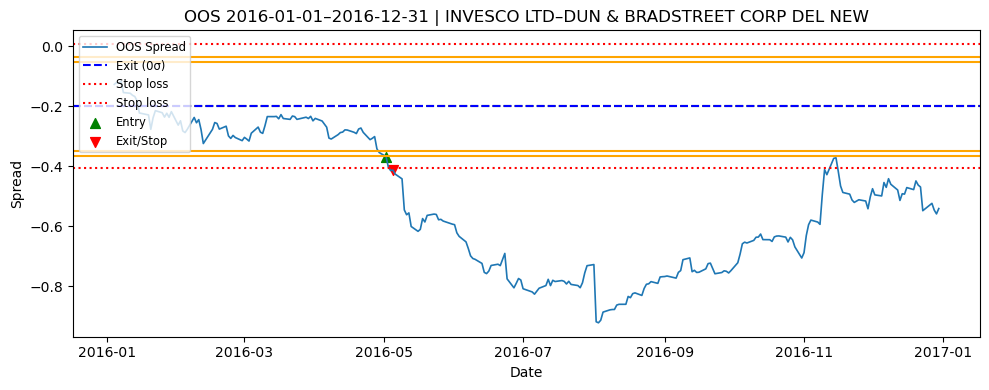

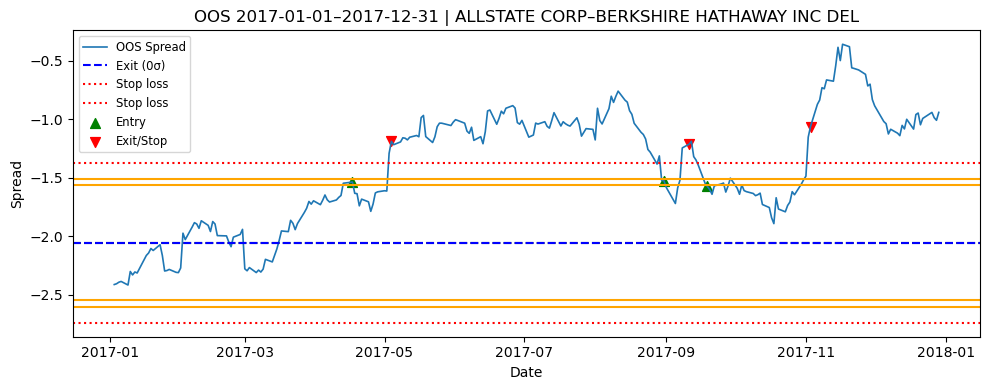

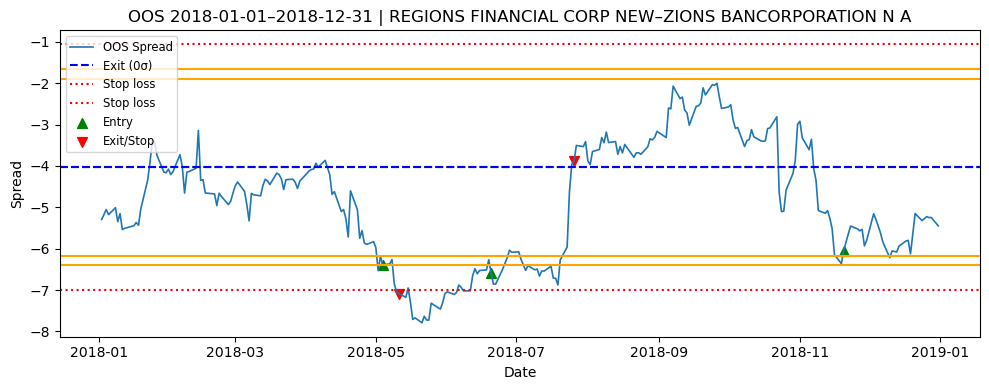

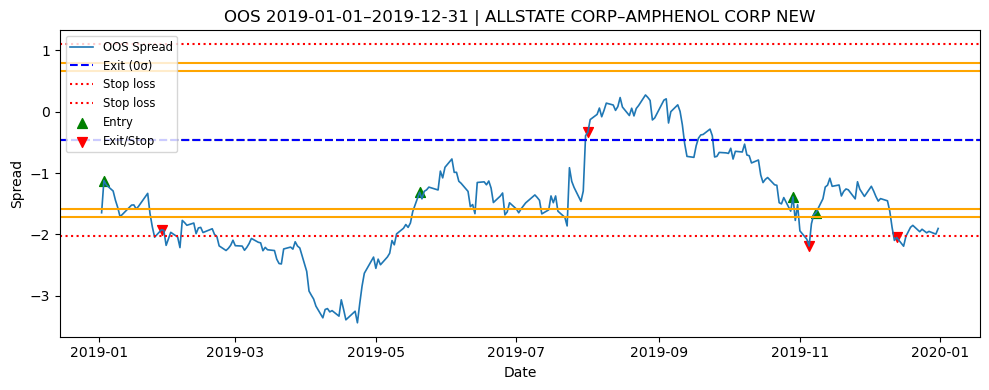

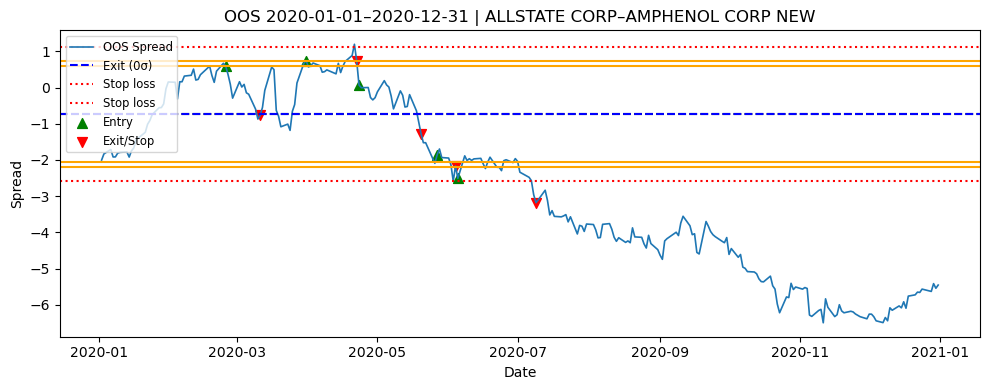

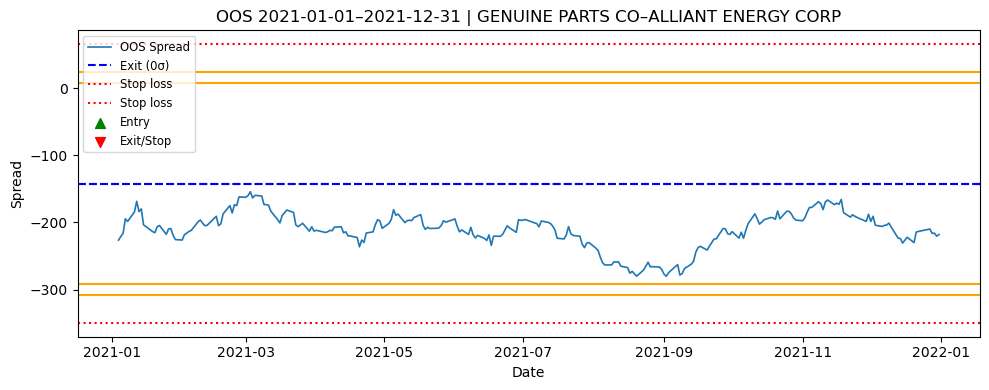

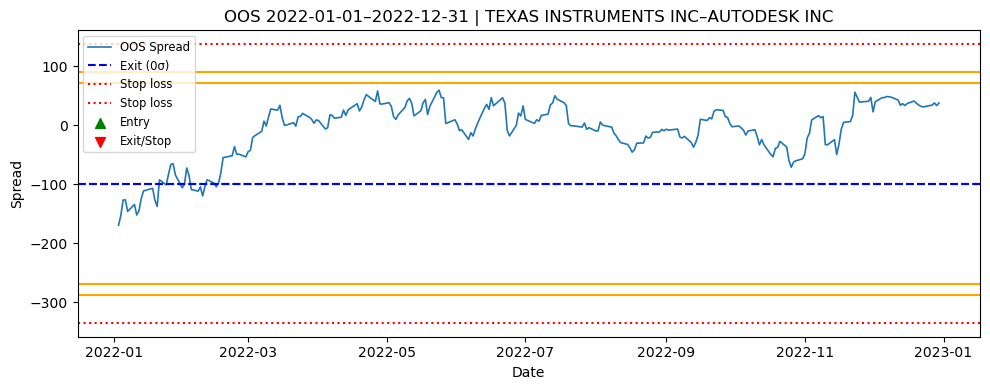

In [180]:
entry_short_lower = 1.8   # 스프레드 매도 진입 하한 (z >= 1.8)
entry_short_upper = 2.0   # 스프레드 매도 진입 상한 (z <= 2.2)
entry_long_upper  = -1.8  # 스프레드 매수 진입 상한 (z <= -1.8)
entry_long_lower  = -2.0  # 스프레드 매수 진입 하한 (z >= -2.2)
exit_level        = 0.0   # 평균회귀 청산 지점 (z = 0)
stop_threshold_up = 2.5   # 손절 상한 (z > 2.2)
stop_threshold_dn = -2.5  # 손절 하한 (z < -2.2)

for row in selection_df.itertuples(index=False):
    IS_s, IS_e   = row.IS_start, row.IS_end
    p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio


    dfIS      = sp500_prices[[p1,p2]].loc[IS_s:IS_e].dropna()
    spread_IS = dfIS[p1] - beta * dfIS[p2]
    mu_sp, sd_sp = spread_IS.mean(), spread_IS.std()

    OOS_s = IS_e + relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))
    dfOOS = sp500_prices[[p1,p2]].loc[OOS_s:OOS_e].dropna()
    if dfOOS.empty:
        continue

    spread_OOS = dfOOS[p1] - beta * dfOOS[p2]
    z = (spread_OOS - mu_sp) / sd_sp

    # 포지션 계산
    pos = np.zeros(len(z), dtype=int)
    for i in range(1, len(z)):
        prev = pos[i-1]
        z_prev = z.iat[i-1]

        # 진입 조건 (포지션 없음)
        if prev == 0:
            # 스프레드 매도 진입
            if entry_short_lower <= z_prev <= entry_short_upper:
                pos[i] = -1
            # 스프레드 매수 진입
            elif entry_long_lower <= z_prev <= entry_long_upper:
                pos[i] =  1

        # 매도 포지션
        elif prev == -1:
            # 청산 혹은 손절 조건건
            if (z_prev <= exit_level) or (z_prev > stop_threshold_up):
                pos[i] = 0
            else:
                pos[i] = -1

        # 매수 포지션
        elif prev == 1:
            # 청산 혹은 손절 조건건
            if (z_prev >= exit_level) or (z_prev < stop_threshold_dn):
                pos[i] = 0
            else:
                pos[i] = 1

    pos = pd.Series(pos, index=z.index)
    prev_pos = pos.shift(1).fillna(0)

    # 진입/청산
    entry_mask = (pos != 0) & (prev_pos == 0)
    exit_mask  = (pos == 0) & (prev_pos != 0)

    ent_up_low  = mu_sp + entry_short_lower * sd_sp
    ent_up_high = mu_sp + entry_short_upper * sd_sp
    ent_dn_high = mu_sp + entry_long_upper  * sd_sp
    ent_dn_low  = mu_sp + entry_long_lower  * sd_sp
    exit_line   = mu_sp + exit_level        * sd_sp
    stop_up     = mu_sp + stop_threshold_up * sd_sp
    stop_dn     = mu_sp + stop_threshold_dn * sd_sp

    plt.figure(figsize=(10, 4))
    plt.plot(spread_OOS.index, spread_OOS, label="OOS Spread", lw=1.2)

    plt.axhline(mu_sp,       color="black", linestyle="--")
    plt.axhline(exit_line,   color="blue",  linestyle="--", label="Exit (0σ)")

    plt.axhline(ent_up_low,  color="orange", linestyle="-")
    plt.axhline(ent_up_high, color="orange", linestyle="-")
    plt.axhline(ent_dn_high, color="orange", linestyle="-")
    plt.axhline(ent_dn_low,  color="orange", linestyle="-")

    plt.axhline(stop_up,     color="red",    linestyle=":", label="Stop loss")
    plt.axhline(stop_dn,     color="red",    linestyle=":", label="Stop loss")

    plt.scatter(spread_OOS.index[entry_mask],
                spread_OOS[entry_mask],
                marker="^", color="green", s=50, label="Entry")
    plt.scatter(spread_OOS.index[exit_mask],
                spread_OOS[exit_mask],
                marker="v", color="red",   s=50, label="Exit/Stop")

    plt.title(f"OOS {OOS_s.date()}–{OOS_e.date()} | {row.comnam_1}–{row.comnam_2}")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend(loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()


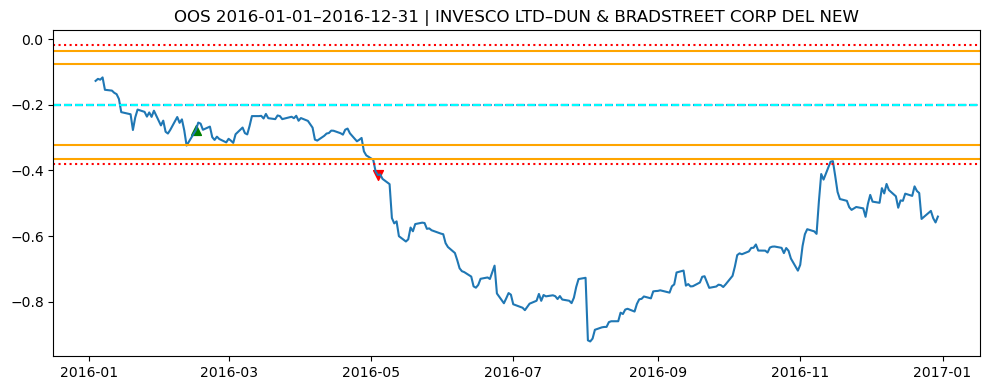

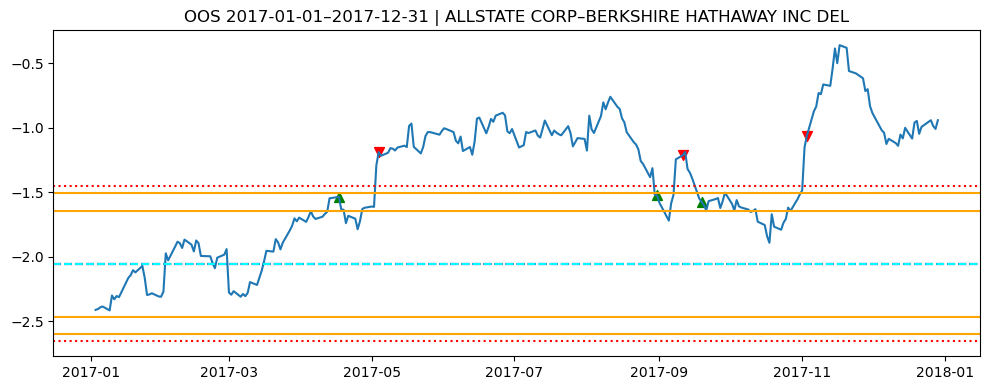

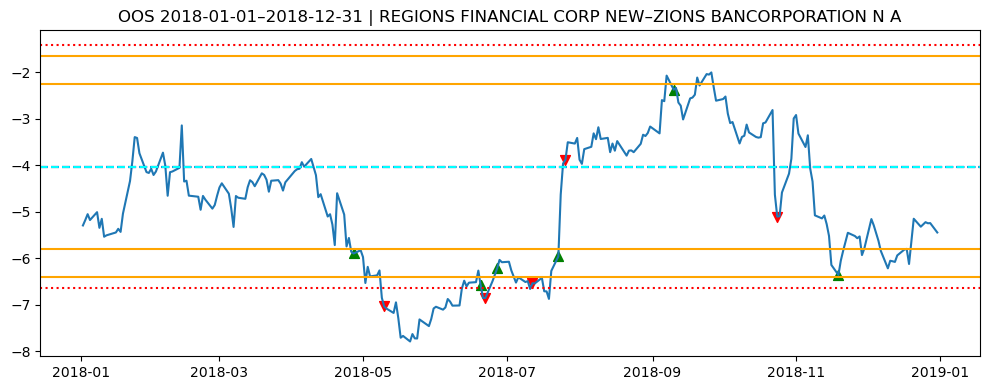

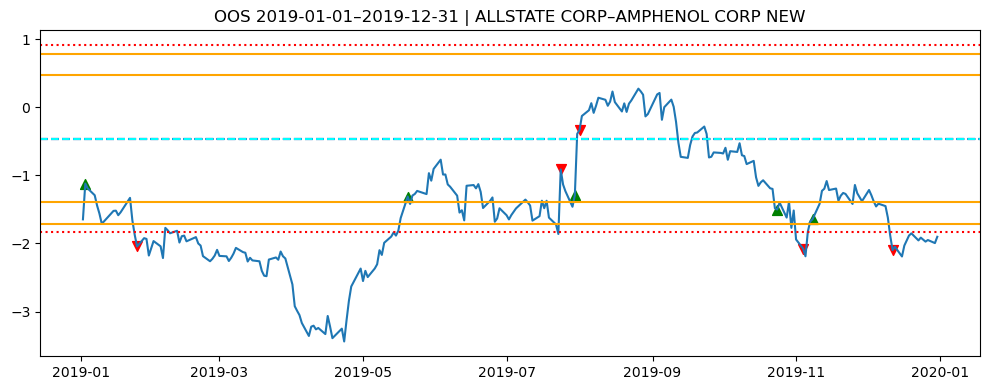

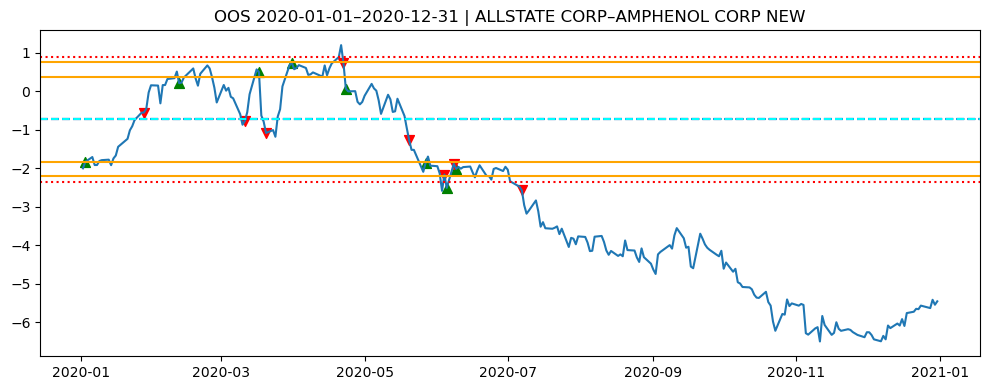

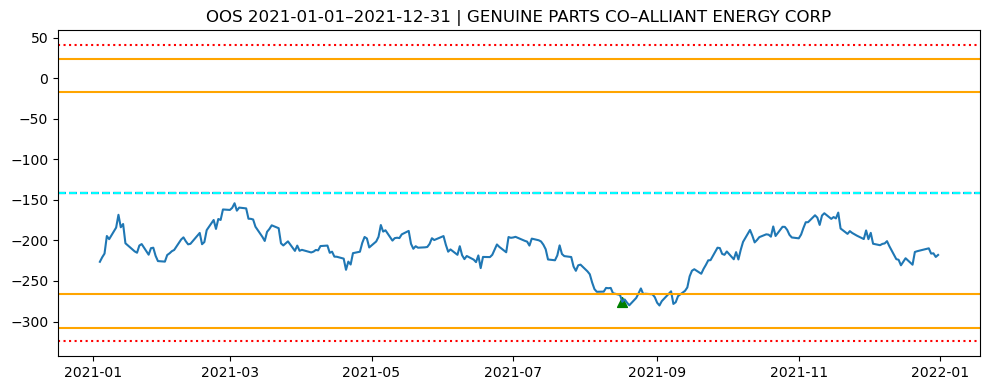

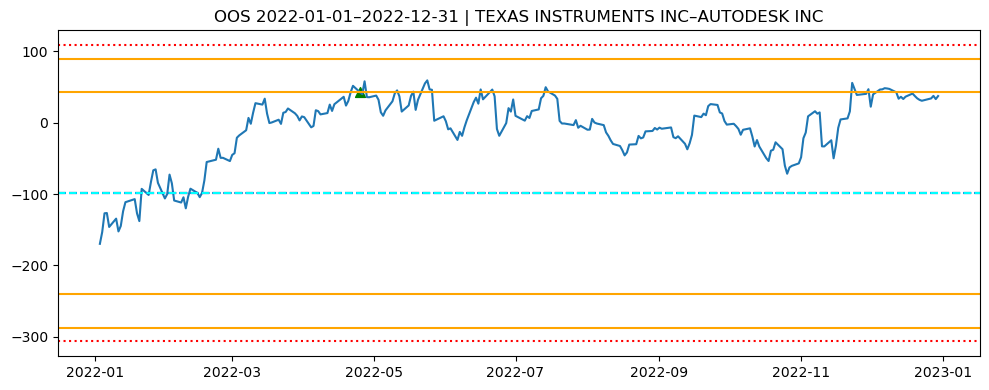

,OOS_start,permno_1,permno_2,total_return,sharpe,max_drawdown,trades,avg_hold
0,2016-01-01,19583,88590,0.064465,0.546764,-0.090826,1,55.000000
1,2017-01-01,79323,83443,-0.111248,-1.557216,-0.138991,3,17.333333
2,2018-01-01,35044,84129,0.037791,0.386099,-0.156942,5,11.200000
3,2019-01-01,79323,84769,0.111400,1.042236,-0.048918,5,18.400000
4,2020-01-01,79323,84769,0.319917,1.159381,-0.174520,8,12.250000
5,2021-01-01,46674,58819,0.098372,0.509795,-0.206374,0,NaN
6,2022-01-01,15579,85631,-0.004559,0.173455,-0.210807,0,NaN


In [ ]:
entry_short_lower  = 1.5   # 스프레드 매도 진입 하한 (z >= 1.5)
entry_short_upper  = 2.0   # 스프레드 매도 진입 상한 (z <= 2.0)
entry_long_upper   = -1.5  # 스프레드 매수 진입 상한 (z <= -1.5)
entry_long_lower   = -2.0  # 스프레드 매수 진입 하한 (z >= -2.0)
exit_short_level   =  0  # 매도 포지션 청산 (z = 0)
exit_long_level    = 0  # 매수 포지션 청산 (z = 0)
stop_threshold_up  =  2.2  # 손절 상한 (z >  2.2)
stop_threshold_dn  = -2.2  # 손절 하한 (z < -2.2)
tc_rate = 0.001
results = []

for row in selection_df.itertuples(index=False):
    IS_s, IS_e   = row.IS_start, row.IS_end
    p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio

    # 1) IS 스프레드 통계
    dfIS      = sp500_prices[[p1,p2]].loc[IS_s:IS_e].dropna()
    spread_IS = dfIS[p1] - beta * dfIS[p2]
    mu_sp, sd_sp = spread_IS.mean(), spread_IS.std()

    # 2) OOS 기간 설정
    OOS_s = IS_e + relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))
    dfOOS = sp500_prices[[p1,p2]].loc[OOS_s:OOS_e].dropna()
    if dfOOS.empty:
        continue

    # 3) OOS 스프레드 & z-score 계산
    spread_OOS = dfOOS[p1] - beta * dfOOS[p2]
    z = (spread_OOS - mu_sp) / sd_sp

    # 4) 포지션 계산 (next-day execution)
    pos = np.zeros(len(z), dtype=int)
    for i in range(1, len(z)):
        prev   = pos[i-1]
        z_prev = z.iat[i-1]

        if prev == 0:
            if entry_short_lower <= z_prev <= entry_short_upper:
                pos[i] = -1
            elif entry_long_lower <= z_prev <= entry_long_upper:
                pos[i] =  1

        elif prev == -1:
            # 매도 유지 / 청산 / 손절
            if (z_prev <= exit_short_level) or (z_prev > stop_threshold_up):
                pos[i] = 0
            else:
                pos[i] = -1

        elif prev == 1:
            # 매수 유지 / 청산 / 손절
            if (z_prev >= exit_long_level) or (z_prev < stop_threshold_dn):
                pos[i] = 0
            else:
                pos[i] = 1

    pos = pd.Series(pos, index=z.index)
    prev_pos = pos.shift(1).fillna(0)

    # 진입/청산 마스크 (플롯용)
    entry_mask = (pos != 0) & (prev_pos == 0)
    exit_mask  = (pos == 0) & (prev_pos != 0)

    # ─── 플롯 (원하시면 실행) ───
    ent_up_low   = mu_sp + entry_short_lower * sd_sp
    ent_up_high  = mu_sp + entry_short_upper * sd_sp
    ent_dn_high  = mu_sp + entry_long_upper  * sd_sp
    ent_dn_low   = mu_sp + entry_long_lower  * sd_sp
    exit_short_l = mu_sp + exit_short_level   * sd_sp
    exit_long_l  = mu_sp + exit_long_level    * sd_sp
    stop_up      = mu_sp + stop_threshold_up  * sd_sp
    stop_dn      = mu_sp + stop_threshold_dn  * sd_sp

    plt.figure(figsize=(10,4))
    plt.plot(spread_OOS.index, spread_OOS, label="OOS Spread")
    plt.axhline(mu_sp,       color="black", linestyle="--", label="IS Mean")
    plt.axhline(exit_short_l, color="blue", linestyle="--", label="Exit Short 0.2σ")
    plt.axhline(exit_long_l,  color="cyan", linestyle="--", label="Exit Long -0.2σ")
    plt.axhline(ent_up_low,   color="orange", linestyle="-", label="Entry Short 1.8σ")
    plt.axhline(ent_up_high,  color="orange", linestyle="-", label="Entry Short 2.2σ")
    plt.axhline(ent_dn_high,  color="orange", linestyle="-", label="Entry Long -1.8σ")
    plt.axhline(ent_dn_low,   color="orange", linestyle="-", label="Entry Long -2.2σ")
    plt.axhline(stop_up,      color="red", linestyle=":", label="Stop Upper 2.2σ")
    plt.axhline(stop_dn,      color="red", linestyle=":", label="Stop Lower -2.2σ")
    plt.scatter(spread_OOS.index[entry_mask], spread_OOS[entry_mask], marker="^", color="green", s=50)
    plt.scatter(spread_OOS.index[exit_mask],  spread_OOS[exit_mask],  marker="v", color="red",   s=50)
    plt.title(f"OOS {OOS_s.date()}–{OOS_e.date()} | {row.comnam_1}–{row.comnam_2}")
    plt.tight_layout()
    plt.show()

    # ─── 전략 일별 수익률 & 성과 지표 계산 ───
    ret1       = sp500.loc[OOS_s:OOS_e, p1]
    ret2       = sp500.loc[OOS_s:OOS_e, p2]
    spread_ret = ret1 - beta * ret2

    trades     = pos.diff().abs().fillna(0)
    costs      = trades * tc_rate * 2
    strat_ret  = pos.shift(1) * spread_ret - costs

    cum        = (1 + strat_ret).cumprod()
    total_ret  = cum.iloc[-1] - 1
    sharpe     = (strat_ret.mean() / strat_ret.std() * np.sqrt(252)
                  if strat_ret.std()>0 else np.nan)
    max_dd     = (cum / cum.cummax() - 1).min()
    ntrades    = int(trades.sum() / 2)
    trade_ix   = np.where(trades.values!=0)[0]
    holds      = np.diff(trade_ix)[::2] if len(trade_ix)>1 else []
    avg_hold   = np.mean(holds) if len(holds)>0 else np.nan

    results.append({
        "OOS_start":    OOS_s,
        "permno_1":     p1,
        "permno_2":     p2,
        "total_return": total_ret,
        "sharpe":       sharpe,
        "max_drawdown": max_dd,
        "trades":       ntrades,
        "avg_hold":     avg_hold
    })

# ─── 성과지표 DataFrame 출력 ───
perf_df = pd.DataFrame(results)
display(perf_df)

포트폴리오 초기 자본: $10,000
총 수익률:       136.07%
연환산 수익률:   13.12%
연환산 변동성:   21.70%
샤프 비율:       0.60
최대 낙폭:       -23.69%


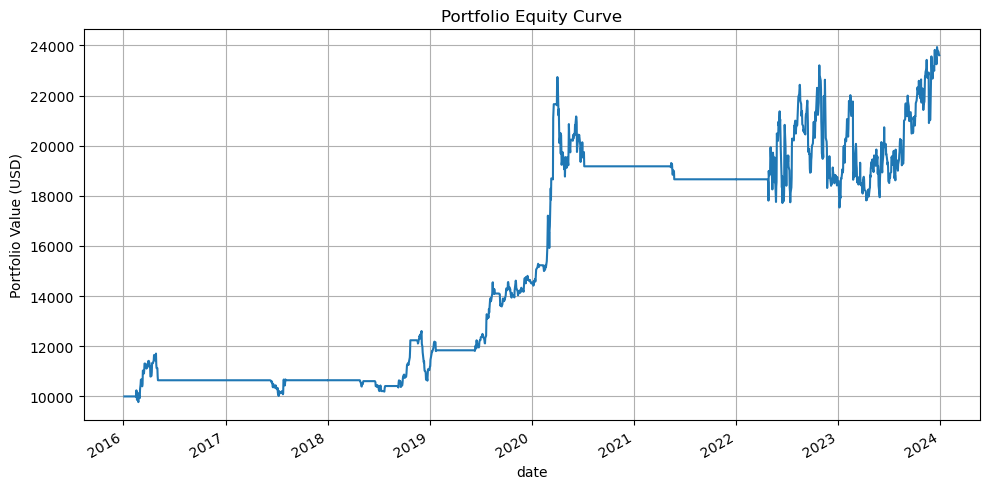

In [174]:
# 1) 페어별 strat_ret 재계산 & 모으기
rets_list = []
for row in selection_df.itertuples(index=False):
    IS_s, IS_e   = row.IS_start, row.IS_end
    p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio

    # IS 스프레드 통계
    dfIS      = sp500_prices[[p1,p2]].loc[IS_s:IS_e].dropna()
    spread_IS = dfIS[p1] - beta * dfIS[p2]
    mu_sp, sd_sp = spread_IS.mean(), spread_IS.std()

    # OOS 기간
    OOS_s = IS_e + relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))
    dfOOS = sp500_prices[[p1,p2]].loc[OOS_s:OOS_e].dropna()
    if dfOOS.empty:
        continue

    # z-score, pos 계산
    spread_OOS = dfOOS[p1] - beta * dfOOS[p2]
    z = (spread_OOS - mu_sp) / sd_sp

    pos = np.zeros(len(z), dtype=int)
    for i in range(1, len(z)):
        prev, z_prev = pos[i-1], z.iat[i-1]
        if prev == 0:
            if entry_short_lower <= z_prev <= entry_short_upper:
                pos[i] = -1
            elif entry_long_lower <= z_prev <= entry_long_upper:
                pos[i] =  1
        elif prev == -1:
            pos[i] = 0 if (z_prev <= exit_short_level or z_prev > stop_threshold_up) else -1
        else:  # prev == 1
            pos[i] = 0 if (z_prev >= exit_long_level or z_prev < stop_threshold_dn) else 1

    pos = pd.Series(pos, index=z.index)

    # 일별 전략 수익률
    ret1       = sp500.loc[OOS_s:OOS_e, p1]
    ret2       = sp500.loc[OOS_s:OOS_e, p2]
    spread_ret = ret1 - beta * ret2

    trades     = pos.diff().abs().fillna(0)
    costs      = trades * tc_rate * 2
    strat_ret  = pos.shift(1) * spread_ret - costs

    # 페어 식별용 컬럼 이름 (예: "2016-01-01_19583_88590")
    key = f"{OOS_s.date()}_{p1}_{p2}"
    strat_ret.name = key
    rets_list.append(strat_ret)

# 2) DataFrame으로 합치기 (NaN은 그대로)
rets_df = pd.concat(rets_list, axis=1)

# 3) 일별 포트폴리오 수익률
#    '활성화된' 페어 수로 나누기 위해 skipna=True 기본 값 이용
port_ret = rets_df.mean(axis=1)

# 4) 누적 자산 곡선
init_cap = 10_000
equity = (1 + port_ret).cumprod() * init_cap

# 5) 포트폴리오 성과 지표
total_return = equity.iloc[-1]/init_cap - 1
ann_return   = port_ret.mean() * 252
ann_vol      = port_ret.std() * np.sqrt(252)
sharpe       = ann_return / ann_vol
roll_max     = equity.cummax()
max_dd       = (equity - roll_max).min()/roll_max.max()

print(f"포트폴리오 초기 자본: ${init_cap:,.0f}")
print(f"총 수익률:       {total_return:.2%}")
print(f"연환산 수익률:   {ann_return:.2%}")
print(f"연환산 변동성:   {ann_vol:.2%}")
print(f"샤프 비율:       {sharpe:.2f}")
print(f"최대 낙폭:       {max_dd:.2%}")

# 6) 그래프 그리기
plt.figure(figsize=(10,5))
equity.plot()
plt.title("Portfolio Equity Curve")
plt.ylabel("Portfolio Value (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [168]:
# ─── 기간 설정 ───
IS_years, OOS_years = 6, 2
first_oos_start    = pd.Timestamp("2016-01-01")
last_oos_start     = pd.Timestamp("2024-12-31") - relativedelta(years=OOS_years)

# 1) 2년 단위로 OOS 시작일 리스트 생성
oos_starts = []
dt = first_oos_start
while dt <= last_oos_start:
    oos_starts.append(dt)
    dt += relativedelta(years=OOS_years)   # <-- 2년씩 점프

selection_records = []

# 2) 각 OOS 윈도우별 페어 선택
for OOS_s in tqdm(oos_starts, desc="OOS windows"):
    IS_s = OOS_s - relativedelta(years=IS_years)
    IS_e = OOS_s - relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))

    # IS 기간에 NaN 하나라도 있는 종목은 제외
    form = sp500_prices.loc[IS_s:IS_e].dropna(axis=1, how="any")

    candidates = []
    for _, row in filtered_pairs.iterrows():
        p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio
        if not (0.2 <= beta <= 3.0): continue
        if p1 not in form or p2 not in form: continue

        df_pair = form[[p1, p2]]
        if len(df_pair) < 252: continue

        # 공적분 테스트
        _, pval_IS, _ = coint(df_pair[p1], df_pair[p2])
        if pval_IS >= 0.01: continue

        # IS 스프레드 분산
        spread_IS   = df_pair[p1] - beta * df_pair[p2]
        var_spread  = spread_IS.var()

        # 추가 지표 로드
        m = metrics_df_1pct.query("permno_1==@p1 & permno_2==@p2").iloc[0]

        candidates.append({
            'OOS_start':   OOS_s,
            'IS_start':    IS_s,
            'IS_end':      IS_e,
            'permno_1':    p1,
            'comnam_1':    m.comnam_1,
            'permno_2':    p2,
            'comnam_2':    m.comnam_2,
            'pval_IS':     pval_IS,
            'hedge_ratio': m.hedge_ratio,
            'var_spread':  var_spread,
            'hurst':       m.hurst,
            'half_life':   m.half_life,
            'mean_cross_year': m.mean_cross_year,
            'pearson_corr':    m.pearson_corr
        })

    if not candidates:
        continue

    cand_df = pd.DataFrame(candidates)

    # var_spread이 가장 작은 페어를 하나 골라 기록
    best = cand_df.loc[cand_df['var_spread'].idxmin()]
    selection_records.append(best.to_dict())

# 3) 결과 정리
selection_df = pd.DataFrame(selection_records)
display(selection_df.reset_index(drop=True))

OOS windows: 100%|██████████| 4/4 [00:42<00:00, 10.54s/it]


,OOS_start,IS_start,IS_end,permno_1,comnam_1,permno_2,comnam_2,pval_IS,hedge_ratio,var_spread,hurst,half_life,mean_cross_year,pearson_corr
0,2016-01-01,2010-01-01,2015-12-31,19583,INVESCO LTD,88590,DUN & BRADSTREET CORP DEL NEW,0.001716,0.247952,0.006805,0.401752,22.434700,17.536008,0.518467
1,2018-01-01,2012-01-01,2017-12-31,35044,REGIONS FINANCIAL CORP NEW,84129,ZIONS BANCORPORATION N A,0.000099,0.432589,1.410385,0.415188,28.038561,10.354595,0.761703
2,2020-01-01,2014-01-01,2019-12-31,79323,ALLSTATE CORP,84769,AMPHENOL CORP NEW,0.004493,0.234324,0.545725,0.358601,26.141570,14.529835,0.565854
3,2022-01-01,2016-01-01,2021-12-31,15579,TEXAS INSTRUMENTS INC,85631,AUTODESK INC,0.008176,1.228057,8898.915804,0.402721,28.116078,12.024691,0.535277


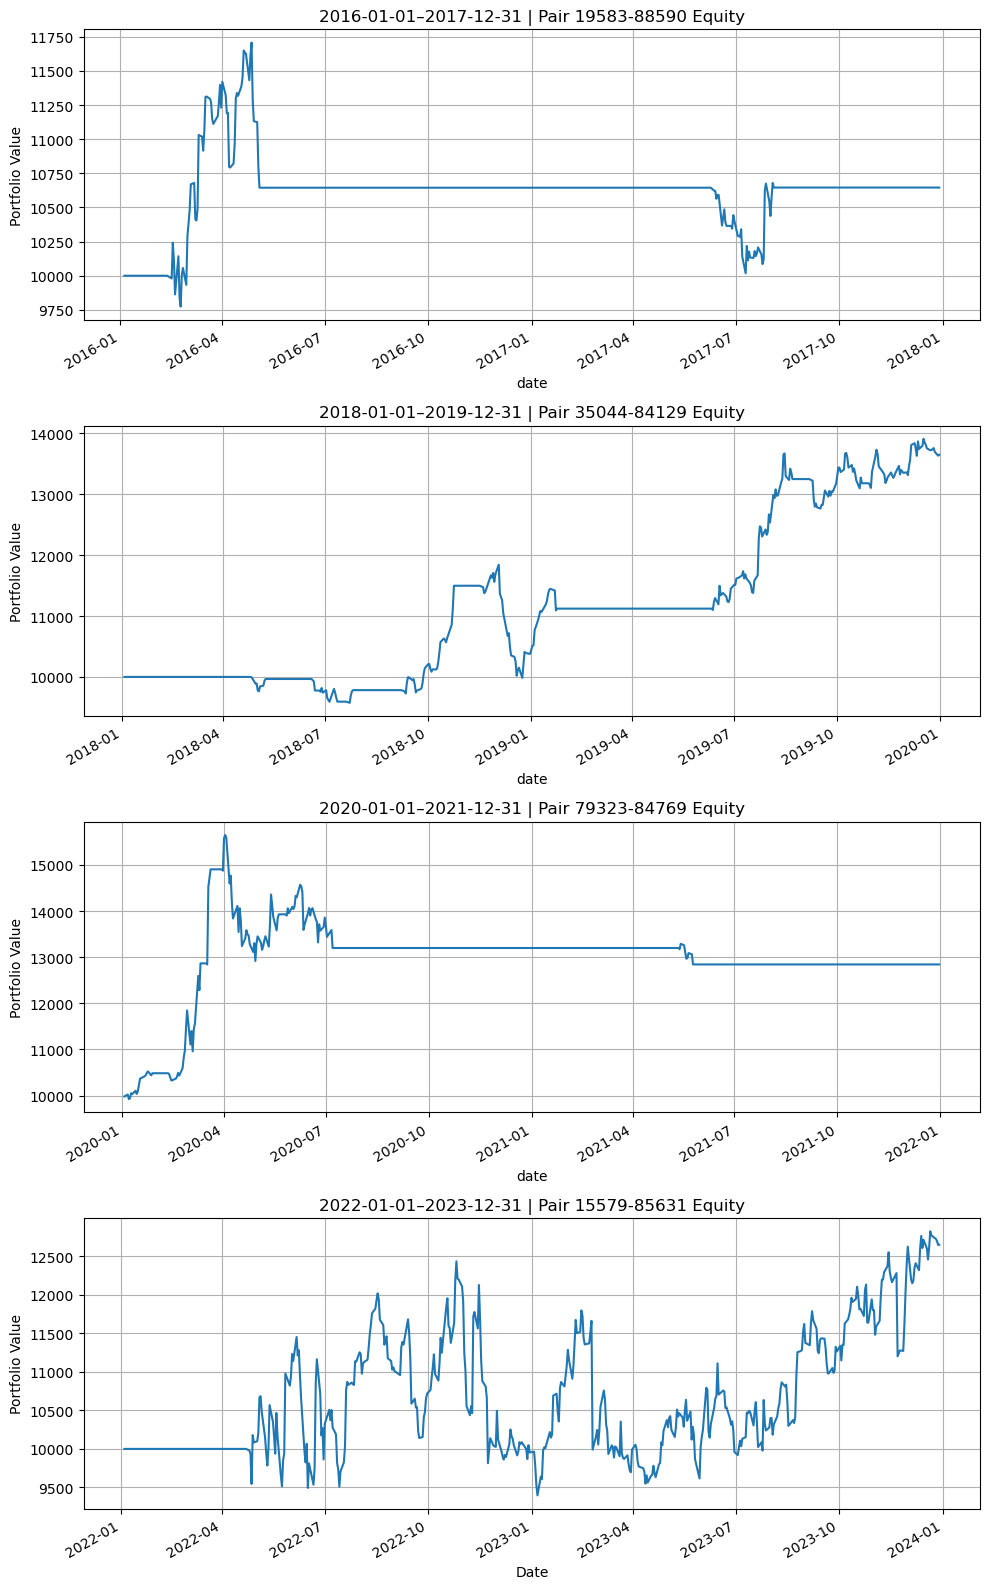

,OOS_start,OOS_end,permno_1,permno_2,total_ret,sharpe,max_drawdown,trades,avg_hold
0,2016-01-01,2017-12-31,19583,88590,0.064586,0.351146,-0.144346,3,30.0
1,2018-01-01,2019-12-31,35044,84129,0.364822,1.332828,-0.133612,9,20.0
2,2020-01-01,2021-12-31,79323,84769,0.284284,0.745159,-0.179316,10,10.5
3,2022-01-01,2023-12-31,15579,85631,0.265115,0.511253,-0.236914,0,NaN


In [169]:
# ─── 임계값 설정 ───
entry_short_lower  = 1.5   # 스프레드 매도 진입 하한 (z >= 1.8)
entry_short_upper  = 2.0   # 스프레드 매도 진입 상한 (z <= 2.2)
entry_long_upper   = -1.5  # 스프레드 매수 진입 상한 (z <= -1.8)
entry_long_lower   = -2.0  # 스프레드 매수 진입 하한 (z >= -2.2)
exit_short_level   =  0  # 매도 포지션 청산 (z <=  0.2)
exit_long_level    = -0  # 매수 포지션 청산 (z >= -0.2)
stop_threshold_up  =  2.2  # 손절 상한 (z >  2.2)
stop_threshold_dn  = -2.2  # 손절 하한 (z < -2.2)
tc_rate = 0.001
results = []
# 1) 결과 저장할 리스트, subplot 행개수
perf_records = []
n = len(selection_df)

fig, axes = plt.subplots(n, 1, figsize=(10, 4*n), sharex=False)

for ax, row in zip(axes, selection_df.itertuples(index=False)):
    # 페어 정보
    OOS_s = row.OOS_start
    OOS_e = min(OOS_s + relativedelta(years=OOS_years)
                - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))
    p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio

    # IS 통계
    dfIS      = sp500_prices[[p1,p2]].loc[row.IS_start:row.IS_end].dropna()
    spread_IS = dfIS[p1] - beta * dfIS[p2]
    mu_sp, sd_sp = spread_IS.mean(), spread_IS.std()

    # OOS 스프레드, z-score
    dfOOS     = sp500_prices[[p1,p2]].loc[OOS_s:OOS_e].dropna()
    spread_OOS= dfOOS[p1] - beta * dfOOS[p2]
    z         = (spread_OOS - mu_sp) / sd_sp

    # 포지션 계산
    pos = np.zeros(len(z), dtype=int)
    for i in range(1, len(z)):
        prev, z_prev = pos[i-1], z.iat[i-1]
        if prev == 0:
            if entry_short_lower <= z_prev <= entry_short_upper:
                pos[i] = -1
            elif entry_long_lower <= z_prev <= entry_long_upper:
                pos[i] =  1
        elif prev == -1:
            pos[i] = 0 if (z_prev <= exit_short_level or z_prev > stop_threshold_up) else -1
        else:
            pos[i] = 0 if (z_prev >= exit_long_level or z_prev < stop_threshold_dn) else 1
    pos = pd.Series(pos, index=z.index)

    # 전략 수익률
    ret1       = sp500.loc[OOS_s:OOS_e, p1]
    ret2       = sp500.loc[OOS_s:OOS_e, p2]
    spread_ret = ret1 - beta * ret2
    trades     = pos.diff().abs().fillna(0)
    costs      = trades * tc_rate * 2
    strat_ret  = pos.shift(1) * spread_ret - costs

    # 누적자산 곡선
    equity = (1 + strat_ret).cumprod() * 10000

    # 성과지표
    total_ret  = equity.iloc[-1]/10000 - 1
    ann_return = strat_ret.mean() * 252
    ann_vol    = strat_ret.std() * np.sqrt(252)
    sharpe     = ann_return / ann_vol if ann_vol>0 else np.nan
    roll_max   = equity.cummax()
    max_dd     = (equity - roll_max).min()/roll_max.max()
    ntrades    = int(trades.sum()/2)
    trade_ix   = np.where(trades.values!=0)[0]
    holds      = np.diff(trade_ix)[::2] if len(trade_ix)>1 else []
    avg_hold   = np.mean(holds) if len(holds)>0 else np.nan

    perf_records.append({
        "OOS_start":    OOS_s,
        "OOS_end":      OOS_e,
        "permno_1":     p1,
        "permno_2":     p2,
        "total_ret":    total_ret,
        "sharpe":       sharpe,
        "max_drawdown": max_dd,
        "trades":       ntrades,
        "avg_hold":     avg_hold
    })

    # 4) 해당 윈도우의 자산 곡선 플롯
    equity.plot(ax=ax)
    ax.set_title(f"{OOS_s.date()}–{OOS_e.date()} | Pair {p1}-{p2} Equity")
    ax.set_ylabel("Portfolio Value")
    ax.grid(True)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

# 5) 성과지표 DataFrame
perf_df = pd.DataFrame(perf_records)
display(perf_df)

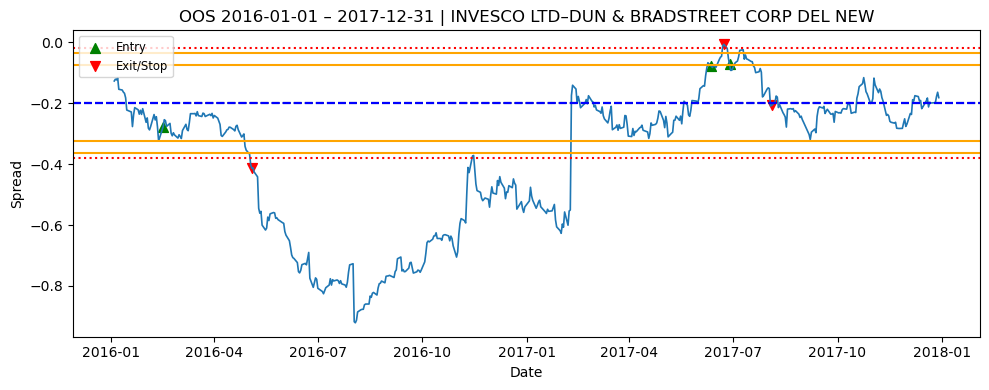

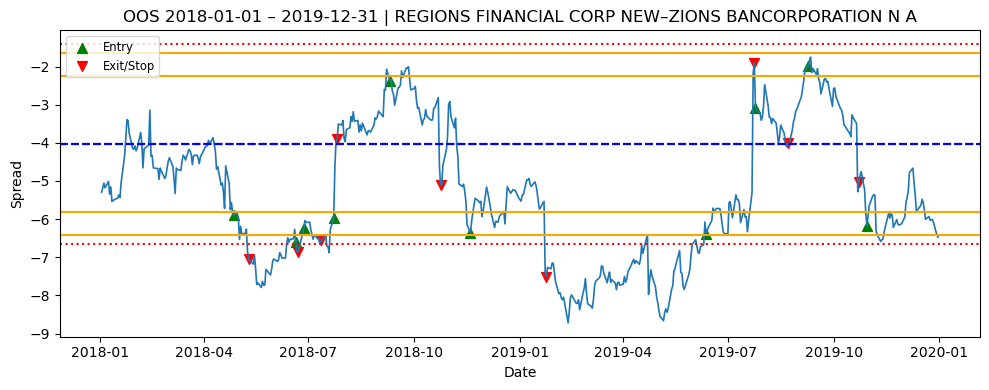

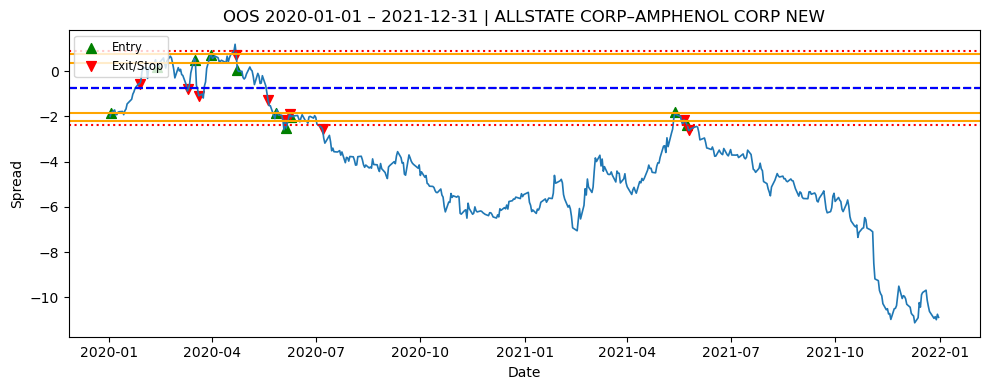

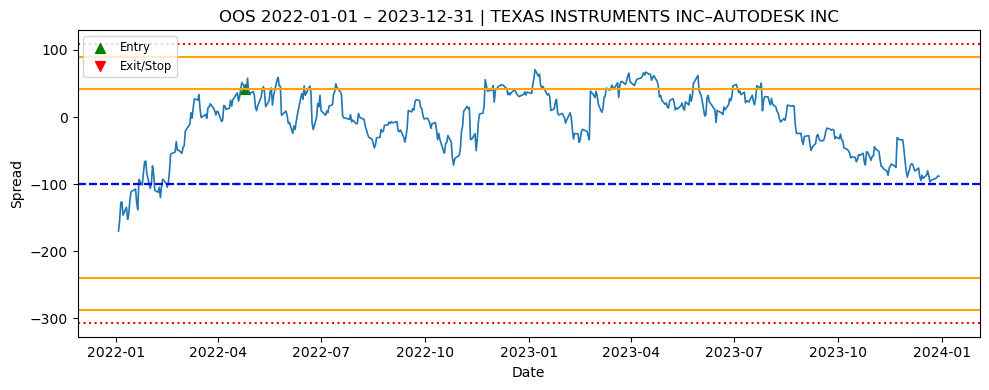

In [170]:
# OOS 윈도우 길이 (2년)
OOS_years = 2

for row in selection_df.itertuples(index=False):
    # IS / OOS 기간 정의
    IS_s, IS_e = row.IS_start, row.IS_end
    OOS_s = IS_e + relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))

    p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio

    # 1) IS 스프레드 통계
    dfIS      = sp500_prices[[p1, p2]].loc[IS_s:IS_e].dropna()
    spread_IS = dfIS[p1] - beta * dfIS[p2]
    mu_sp, sd_sp = spread_IS.mean(), spread_IS.std()

    # 2) OOS 스프레드 & z-score
    dfOOS     = sp500_prices[[p1, p2]].loc[OOS_s:OOS_e].dropna()
    spread_OOS= dfOOS[p1] - beta * dfOOS[p2]
    z         = (spread_OOS - mu_sp) / sd_sp

    # 3) 포지션 계산
    pos = np.zeros(len(z), dtype=int)
    for i in range(1, len(z)):
        prev, z_prev = pos[i-1], z.iat[i-1]
        if prev == 0:
            if entry_short_lower <= z_prev <= entry_short_upper:
                pos[i] = -1
            elif entry_long_lower <= z_prev <= entry_long_upper:
                pos[i] =  1
        elif prev == -1:
            pos[i] = 0 if (z_prev <= exit_short_level or z_prev > stop_threshold_up) else -1
        else:  # prev == 1
            pos[i] = 0 if (z_prev >= exit_long_level or z_prev < stop_threshold_dn) else 1

    pos = pd.Series(pos, index=z.index)
    prev_pos  = pos.shift(1).fillna(0)

    # 4) 진입 / 청산 마스크
    entry_mask = (pos != 0) & (prev_pos == 0)
    exit_mask  = (pos == 0) & (prev_pos != 0)

    # 5) 플롯
    ent_up_low   = mu_sp + entry_short_lower * sd_sp
    ent_up_high  = mu_sp + entry_short_upper * sd_sp
    ent_dn_high  = mu_sp + entry_long_upper  * sd_sp
    ent_dn_low   = mu_sp + entry_long_lower  * sd_sp
    exit_short_l = mu_sp + exit_short_level   * sd_sp
    exit_long_l  = mu_sp + exit_long_level    * sd_sp
    stop_up      = mu_sp + stop_threshold_up  * sd_sp
    stop_dn      = mu_sp + stop_threshold_dn  * sd_sp

    plt.figure(figsize=(10,4))
    plt.plot(spread_OOS.index, spread_OOS, lw=1.2)
    plt.axhline(mu_sp,        color="black", linestyle="--")
    plt.axhline(exit_short_l, color="blue",  linestyle="--")
    plt.axhline(exit_long_l,  color="blue",  linestyle="--")
    plt.axhline(ent_up_low,   color="orange", linestyle="-")
    plt.axhline(ent_up_high,  color="orange", linestyle="-")
    plt.axhline(ent_dn_high,  color="orange", linestyle="-")
    plt.axhline(ent_dn_low,   color="orange", linestyle="-")
    plt.axhline(stop_up,      color="red",    linestyle=":")
    plt.axhline(stop_dn,      color="red",    linestyle=":",)
    plt.scatter(spread_OOS.index[entry_mask], spread_OOS[entry_mask],
                marker="^", color="green", s=50, label="Entry")
    plt.scatter(spread_OOS.index[exit_mask],  spread_OOS[exit_mask],
                marker="v", color="red",   s=50, label="Exit/Stop")

    plt.title(f"OOS {OOS_s.date()} – {OOS_e.date()} | {row.comnam_1}–{row.comnam_2}")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend(loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

포트폴리오 초기 자본: $10,000
총 수익률:       136.07%
연환산 수익률:   13.12%
연환산 변동성:   21.70%
샤프 비율:       0.60
최대 낙폭:       -23.69%


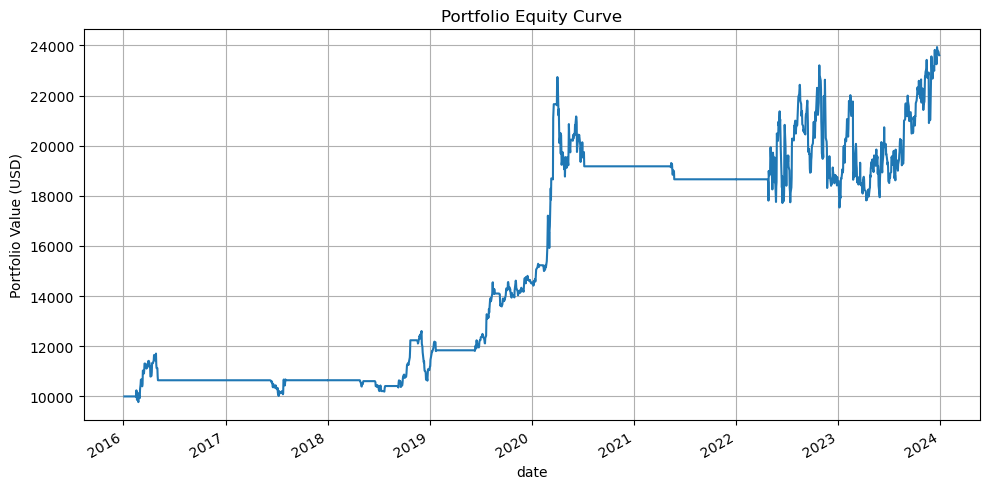

In [171]:
# 1) 페어별 strat_ret 재계산 & 모으기
rets_list = []
for row in selection_df.itertuples(index=False):
    IS_s, IS_e   = row.IS_start, row.IS_end
    p1, p2, beta = row.permno_1, row.permno_2, row.hedge_ratio

    # IS 스프레드 통계
    dfIS      = sp500_prices[[p1,p2]].loc[IS_s:IS_e].dropna()
    spread_IS = dfIS[p1] - beta * dfIS[p2]
    mu_sp, sd_sp = spread_IS.mean(), spread_IS.std()

    # OOS 기간
    OOS_s = IS_e + relativedelta(days=1)
    OOS_e = min(OOS_s + relativedelta(years=OOS_years) - relativedelta(days=1),
                pd.Timestamp("2024-12-31"))
    dfOOS = sp500_prices[[p1,p2]].loc[OOS_s:OOS_e].dropna()
    if dfOOS.empty:
        continue

    # z-score, pos 계산
    spread_OOS = dfOOS[p1] - beta * dfOOS[p2]
    z = (spread_OOS - mu_sp) / sd_sp

    pos = np.zeros(len(z), dtype=int)
    for i in range(1, len(z)):
        prev, z_prev = pos[i-1], z.iat[i-1]
        if prev == 0:
            if entry_short_lower <= z_prev <= entry_short_upper:
                pos[i] = -1
            elif entry_long_lower <= z_prev <= entry_long_upper:
                pos[i] =  1
        elif prev == -1:
            pos[i] = 0 if (z_prev <= exit_short_level or z_prev > stop_threshold_up) else -1
        else:  # prev == 1
            pos[i] = 0 if (z_prev >= exit_long_level or z_prev < stop_threshold_dn) else 1

    pos = pd.Series(pos, index=z.index)

    # 일별 전략 수익률
    ret1       = sp500.loc[OOS_s:OOS_e, p1]
    ret2       = sp500.loc[OOS_s:OOS_e, p2]
    spread_ret = ret1 - beta * ret2

    trades     = pos.diff().abs().fillna(0)
    costs      = trades * tc_rate * 2
    strat_ret  = pos.shift(1) * spread_ret - costs

    # 페어 식별용 컬럼 이름 (예: "2016-01-01_19583_88590")
    key = f"{OOS_s.date()}_{p1}_{p2}"
    strat_ret.name = key
    rets_list.append(strat_ret)

# 2) DataFrame으로 합치기 (NaN은 그대로)
rets_df = pd.concat(rets_list, axis=1)

# 3) 일별 포트폴리오 수익률
#    '활성화된' 페어 수로 나누기 위해 skipna=True 기본 값 이용
port_ret = rets_df.mean(axis=1)

# 4) 누적 자산 곡선
init_cap = 10_000
equity = (1 + port_ret).cumprod() * init_cap

# 5) 포트폴리오 성과 지표
total_return = equity.iloc[-1]/init_cap - 1
ann_return   = port_ret.mean() * 252
ann_vol      = port_ret.std() * np.sqrt(252)
sharpe       = ann_return / ann_vol
roll_max     = equity.cummax()
max_dd       = (equity - roll_max).min()/roll_max.max()

print(f"포트폴리오 초기 자본: ${init_cap:,.0f}")
print(f"총 수익률:       {total_return:.2%}")
print(f"연환산 수익률:   {ann_return:.2%}")
print(f"연환산 변동성:   {ann_vol:.2%}")
print(f"샤프 비율:       {sharpe:.2f}")
print(f"최대 낙폭:       {max_dd:.2%}")

# 6) 그래프 그리기
plt.figure(figsize=(10,5))
equity.plot()
plt.title("Portfolio Equity Curve")
plt.ylabel("Portfolio Value (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()